In [1]:
import glob
import multiprocessing as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from pyBioInfo.IO.File import BedFile
from statsmodels.stats.multitest import multipletests

# Make pairwise transcripts

In [23]:
def make_pairwise_transcripts(infile, outfile):
    rows = []
    d = pd.read_csv(infile)
    d = d[d["Total"] > 0]
    for gid, tmp in sorted(d.groupby(by="GeneID")):
        if len(tmp) == 1:
            continue
        tmp = tmp.sort_values(by="Total", ascending=False)
        for i in range(tmp.shape[0]):
            for j in range(tmp.shape[0]):
                if i == j:
                    continue

                gtype = tmp["GeneType"].values[i]
                gname = tmp["GeneName"].values[i]
                chrom = tmp["Chrom"].values[i]
                start = tmp["Start"].values[i]
                end = tmp["End"].values[i]
                strand = tmp["Strand"].values[i]
        
                tid1, tid2 = tmp["TranscriptID"].values[i], tmp["TranscriptID"].values[j]
                tname1, tname2 = tmp["TranscriptName"].values[i], tmp["TranscriptName"].values[j]
                ttype1, ttype2 = tmp["TranscriptType"].values[i], tmp["TranscriptType"].values[j]
                total1, total2 = tmp["Total"].values[i], tmp["Total"].values[j]
                new1, new2 = tmp["New"].values[i], tmp["New"].values[j]
                ntr1, ntr2 = tmp["NTR"].values[i], tmp["NTR"].values[j]
                t1, t2 = tmp["Halflife"].values[i], tmp["Halflife"].values[j]
                a1, a2 = tmp["TPM"].values[i], tmp["TPM"].values[j]
                old1, old2 = total1 - new1, total2 - new2
                pvalue = fisher_exact([[old1, new1], [old2, new2]])[1]
                rows.append([
                    gid, 
                    gtype, gname, chrom, start, end, strand,
                    tid1, tname1, ttype1, total1, new1, ntr1, t1, a1,
                    tid2, tname2, ttype2, total2, new2, ntr2, t2, a2,
                    pvalue
                ])
    
    m = pd.DataFrame(rows)
    m.columns = [
        "GeneID", 
        "GeneType", "GeneName", "Chrom", "Start", "End", "Strand",
        "TranscriptID.1", "TranscriptName.1", "TranscriptType.1", "Total.1", "New.1", "NTR.1", "Halflife.1", "TPM.1", 
        "TranscriptID.2", "TranscriptName.2", "TranscriptType.2", "Total.2", "New.2", "NTR.2", "Halflife.2", "TPM.2", 
        "Pvalue"
    ]
    m["Total.Min"] = m[["Total.1", "Total.2"]].min(axis=1)
    m["NTR.Diff"] = m["NTR.2"] - m["NTR.1"]
    m.to_csv(outfile, index=False)


pool = mp.Pool(24)
rets = []
for infile in sorted(glob.glob("../3_pseudobulk/results/pseudobulk/*.transcript_based.annotated.csv")):
    print(infile)
    name = infile.split("/")[-1].split(".transcript_based.")[0]
    outfile = "results/pairwise_transcripts/%s.csv" % name
    rets.append(pool.apply_async(make_pairwise_transcripts, (infile, outfile)))
pool.close()
pool.join()
for r in rets:
    r.get()

../3_pseudobulk/results/pseudobulk/K562.s4U_0uM_3h.transcript_based.annotated.csv
../3_pseudobulk/results/pseudobulk/K562.s4U_100uM_3h.transcript_based.annotated.csv
../3_pseudobulk/results/pseudobulk/K562.s4U_200uM_3h.transcript_based.annotated.csv
../3_pseudobulk/results/pseudobulk/K562.s4U_400uM_3h.transcript_based.annotated.csv
../3_pseudobulk/results/pseudobulk/K562.s4U_500uM_3h.transcript_based.annotated.csv
../3_pseudobulk/results/pseudobulk/K562.s4U_50uM_15min.transcript_based.annotated.csv
../3_pseudobulk/results/pseudobulk/K562.s4U_50uM_1h.transcript_based.annotated.csv
../3_pseudobulk/results/pseudobulk/K562.s4U_50uM_2h.transcript_based.annotated.csv
../3_pseudobulk/results/pseudobulk/K562.s4U_50uM_30min.transcript_based.annotated.csv
../3_pseudobulk/results/pseudobulk/K562.s4U_50uM_3h.highTC.transcript_based.annotated.csv
../3_pseudobulk/results/pseudobulk/K562.s4U_50uM_3h.transcript_based.annotated.csv
../3_pseudobulk/results/pseudobulk/K562.transcript_based.annotated.csv


# Plot change of NTR (mRNA vs. RI)

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_15min


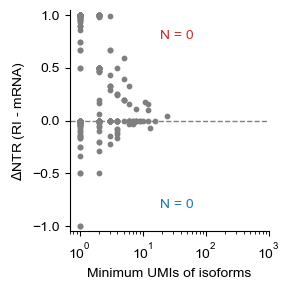

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_1h


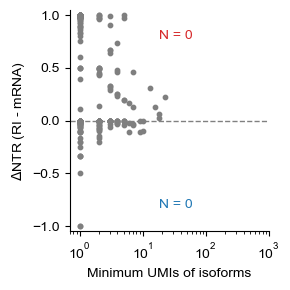

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_2h


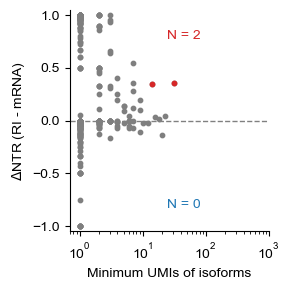

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_30min


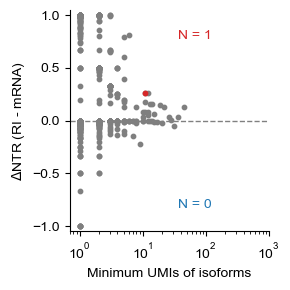

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_3h


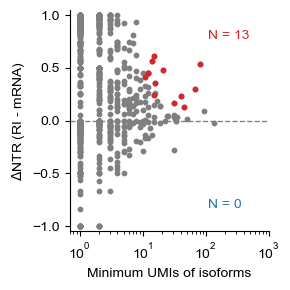

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_3h.highTC


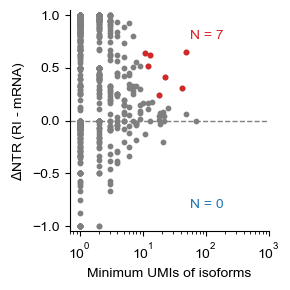

--------------------------------------------------------------------------------
Name: K562_FUCCI_G1.s4U_50uM_2h


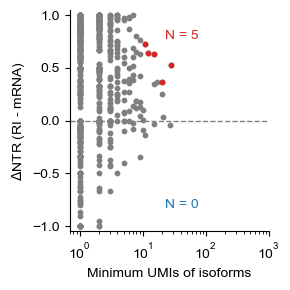

--------------------------------------------------------------------------------
Name: K562_FUCCI_G1.s4U_50uM_3h


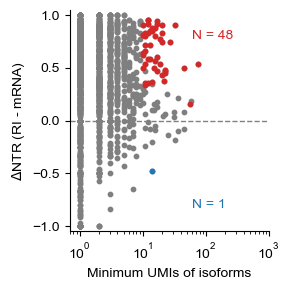

--------------------------------------------------------------------------------
Name: K562_FUCCI_G2M.s4U_50uM_3h


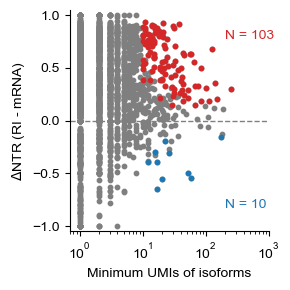

--------------------------------------------------------------------------------
Name: K562_FUCCI_S1.s4U_50uM_3h


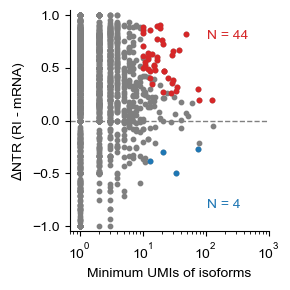

--------------------------------------------------------------------------------
Name: K562_FUCCI_S2.s4U_50uM_3h


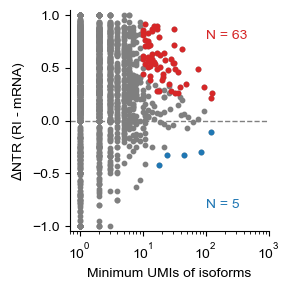

--------------------------------------------------------------------------------
Name: MouseBlastocyst_EPI.s4U_400uM_3h
Mrpl57-201
Mrpl57-202
Mrpl57	42	0.5924185463659148


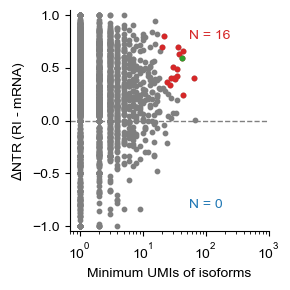

--------------------------------------------------------------------------------
Name: MouseBlastocyst_EarlyTE.s4U_400uM_3h


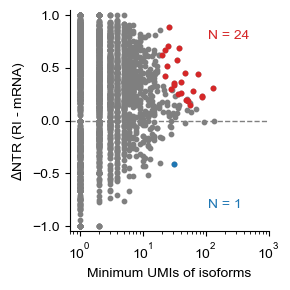

--------------------------------------------------------------------------------
Name: MouseBlastocyst_ICM-1.s4U_400uM_3h


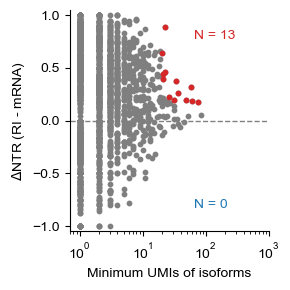

--------------------------------------------------------------------------------
Name: MouseBlastocyst_ICM-2.s4U_400uM_3h


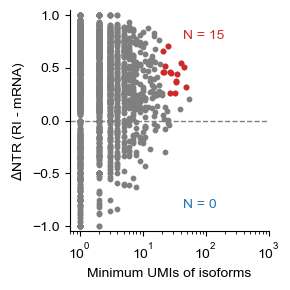

--------------------------------------------------------------------------------
Name: MouseBlastocyst_ICM.s4U_400uM_3h


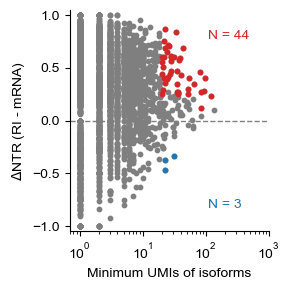

--------------------------------------------------------------------------------
Name: MouseBlastocyst_LateTE.s4U_400uM_3h


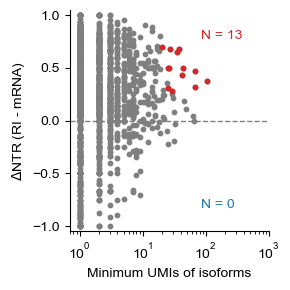

--------------------------------------------------------------------------------
Name: MouseBlastocyst_PE.s4U_400uM_3h


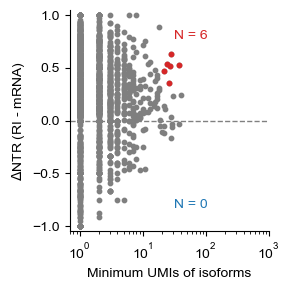

--------------------------------------------------------------------------------
Name: MouseBlastocyst_TE-1.s4U_400uM_3h


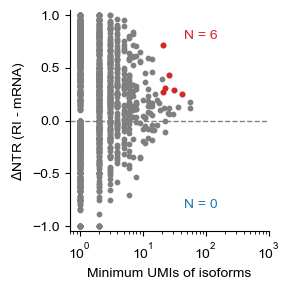

--------------------------------------------------------------------------------
Name: MouseBlastocyst_TE-2.s4U_400uM_3h


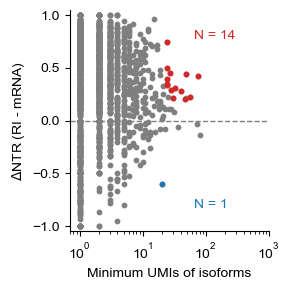

--------------------------------------------------------------------------------
Name: MouseBlastocyst_muralTE.s4U_400uM_3h


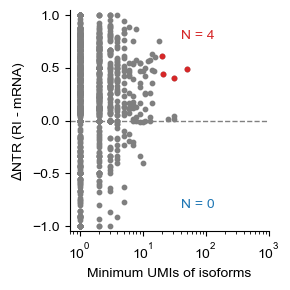

--------------------------------------------------------------------------------
Name: MouseBlastocyst_polarTE.s4U_400uM_3h


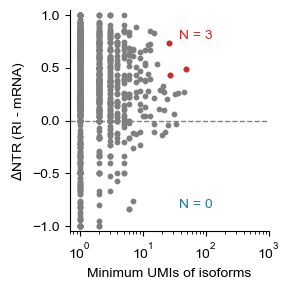

--------------------------------------------------------------------------------
Name: mESC.s4U_400uM_3h


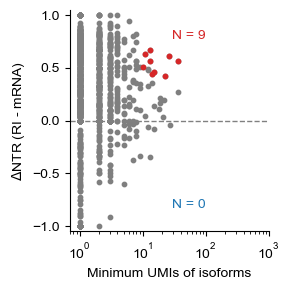

--------------------------------------------------------------------------------
Name: mESC.s4U_400uM_3h.highTC


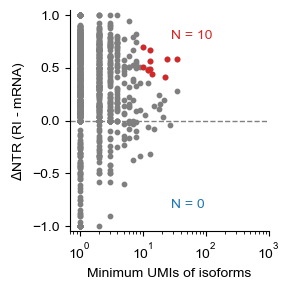

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_0h.s4U_400uM_1h


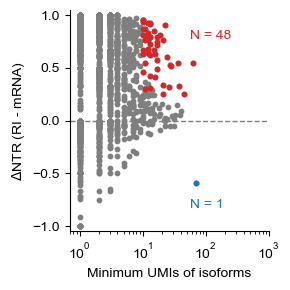

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_0h.s4U_400uM_3h


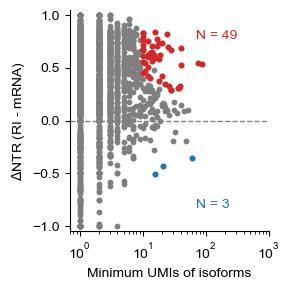

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_12h.s4U_400uM_1h


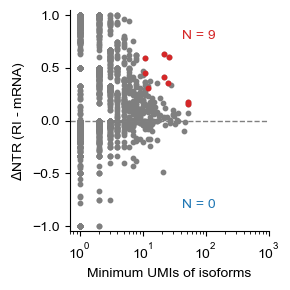

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_12h.s4U_400uM_3h


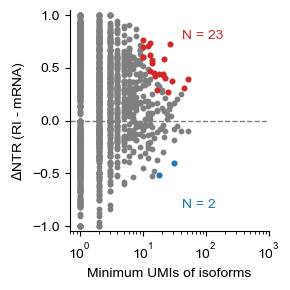

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_4h.s4U_400uM_1h


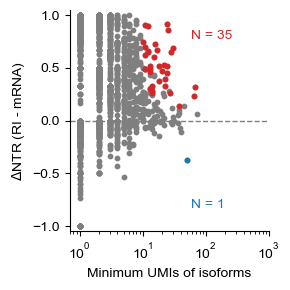

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_4h.s4U_400uM_3h


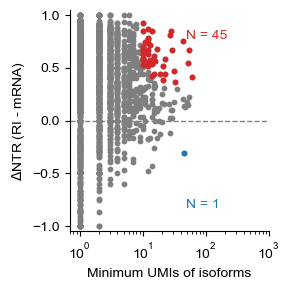

In [28]:
def plot_change_of_ntr_mRNA_RI(infile, min_umis=20, diff_ntr=0.1, pval=0.05, fdr=None, outfile=None, outfile2=None):
    m = pd.read_csv(infile)
    m = m[(m["TranscriptType.1"] == "protein_coding") & (m["TranscriptType.2"] == "retained_intron")]
    m = m[~m["GeneID"].duplicated()]

    # NTR
    tmp = m[m["Total.Min"] >= min_umis].copy()
    tmp["FDR"] = multipletests(tmp["Pvalue"], method='fdr_bh')[1]
    if fdr is not None:
        m1 = tmp[(tmp["NTR.Diff"] > diff_ntr) & (tmp["FDR"] < fdr)]
        m2 = tmp[(tmp["NTR.Diff"] < -diff_ntr) & (tmp["FDR"] < fdr)]
    else:
        m1 = tmp[(tmp["NTR.Diff"] > diff_ntr) & (tmp["Pvalue"] < pval)]
        m2 = tmp[(tmp["NTR.Diff"] < -diff_ntr) & (tmp["Pvalue"] < pval)]
    xs, ys = m["Total.Min"], m["NTR.Diff"]
    xs1, ys1 = m1["Total.Min"], m1["NTR.Diff"]
    xs2, ys2 = m2["Total.Min"], m2["NTR.Diff"]
    if outfile2:
        m.merge(tmp[["FDR"]], left_index=True, right_index=True, how="left").to_csv(outfile2, index=False)
        
    # Plot
    s = 10
    plt.figure(figsize=(3, 3))
    plt.scatter(xs, ys, marker="o", s=s, color="C7", clip_on=False)
    plt.scatter(xs1, ys1, marker="o", s=s, color="C3", clip_on=False)
    plt.scatter(xs2, ys2, marker="o", s=s, color="C0", clip_on=False)
    plt.axhline(0, lw=1, ls="--", color="grey")

    if True and "EPI" in infile:
        highlight_genes = ["Mrpl57"]
        for gname in highlight_genes:
            tmp = m[m["GeneName"] == gname]
            print(tmp["TranscriptName.1"].values[0])
            print(tmp["TranscriptName.2"].values[0])
            xs3, ys3 = tmp["Total.Min"].values, tmp["NTR.Diff"].values
            print(gname, xs3[0], ys3[0], sep="\t")
            plt.scatter(xs3, ys3, marker="o", s=10, color="C2", clip_on=False)
            
    plt.xlabel("Minimum UMIs of isoforms")
    plt.ylabel("$\Delta$NTR (RI - mRNA)")
    plt.xscale("log")
    plt.xlim(0.7, 1000)
    plt.ylim(-1.05, 1.05)
    plt.yticks([-1, -0.5, 0, 0.5, 1])
    xmax = max(xs)
    plt.text(xmax * 0.8, 0.8, "N = %d" % len(xs1), color="C3", va="center")
    plt.text(xmax * 0.8, -0.8, "N = %d" % len(xs2), color="C0", va="center")
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile)
    plt.show()
    plt.close()

for path in sorted(glob.glob("results/pairwise_transcripts/*.csv")):
    name = path.split("/")[-1][:-4]
    if name.startswith("K562") and "s4U_50uM" not in name:
        continue
    if name.startswith("mESC") and "s4U_400uM" not in name:
        continue
    if name.startswith("MouseBlastocyst") and "s4U_400uM" not in name:
        continue

    print("-" * 80)
    print("Name:", name)
    
    plot_change_of_ntr_mRNA_RI(
        infile=path,
        min_umis=20 if name.startswith("MouseBlastocyst") else 10, # 10 or 20
        diff_ntr=0.1,
        fdr=0.01, # 0.05 or 0.01
        outfile="figures/change_of_ntr/change_of_ntr.mRNA_RI.%s.pdf" % name,
        outfile2="results/change_of_ntr/%s.mRNA_RI.csv" % name,
    )
    # break

# Plot change of halflife (mRNA vs. RI)

--------------------------------------------------------------------------------
Path: results/change_of_ntr/K562.s4U_50uM_15min.mRNA_RI.csv
All: 8
protein_coding longer: 0
retained_intron longer 0


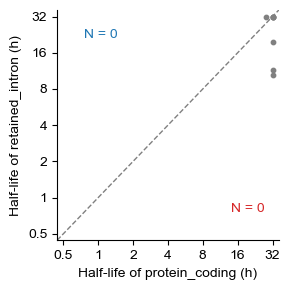

--------------------------------------------------------------------------------
Path: results/change_of_ntr/K562.s4U_50uM_1h.mRNA_RI.csv
All: 7
protein_coding longer: 1
retained_intron longer 0


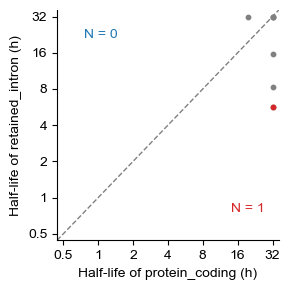

--------------------------------------------------------------------------------
Path: results/change_of_ntr/K562.s4U_50uM_2h.mRNA_RI.csv
All: 8
protein_coding longer: 2
retained_intron longer 0


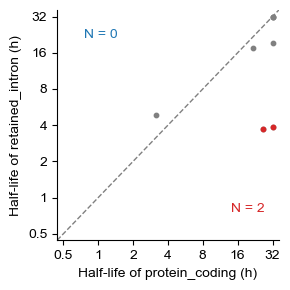

--------------------------------------------------------------------------------
Path: results/change_of_ntr/K562.s4U_50uM_30min.mRNA_RI.csv
All: 26
protein_coding longer: 5
retained_intron longer 0


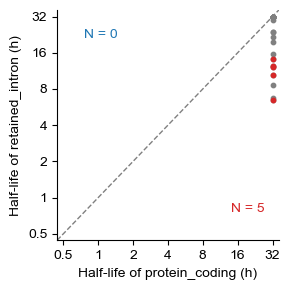

--------------------------------------------------------------------------------
Path: results/change_of_ntr/K562.s4U_50uM_3h.highTC.mRNA_RI.csv
All: 25
protein_coding longer: 7
retained_intron longer 0


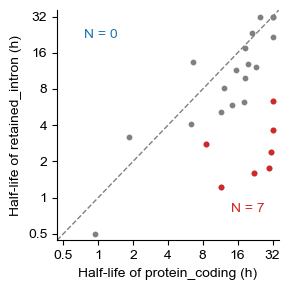

--------------------------------------------------------------------------------
Path: results/change_of_ntr/K562.s4U_50uM_3h.mRNA_RI.csv
All: 54
protein_coding longer: 19
retained_intron longer 1


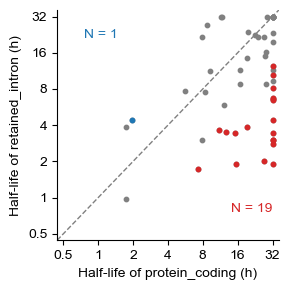

--------------------------------------------------------------------------------
Path: results/change_of_ntr/K562_FUCCI_G1.s4U_50uM_2h.mRNA_RI.csv
All: 15
protein_coding longer: 8
retained_intron longer 0


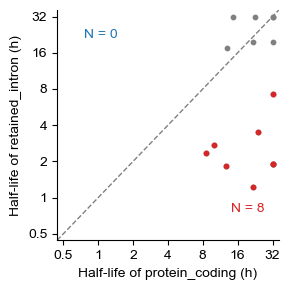

--------------------------------------------------------------------------------
Path: results/change_of_ntr/K562_FUCCI_G1.s4U_50uM_3h.mRNA_RI.csv
All: 80
protein_coding longer: 52
retained_intron longer 1


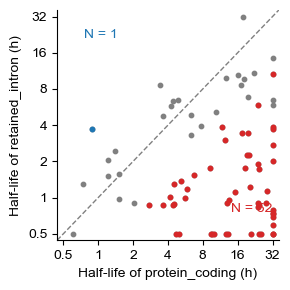

--------------------------------------------------------------------------------
Path: results/change_of_ntr/K562_FUCCI_G2M.s4U_50uM_3h.mRNA_RI.csv
All: 224
protein_coding longer: 127
retained_intron longer 13


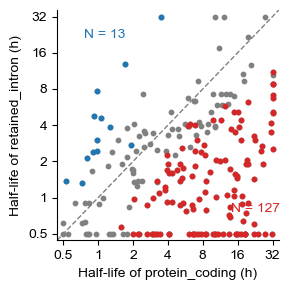

--------------------------------------------------------------------------------
Path: results/change_of_ntr/K562_FUCCI_S1.s4U_50uM_3h.mRNA_RI.csv
All: 101
protein_coding longer: 52
retained_intron longer 7


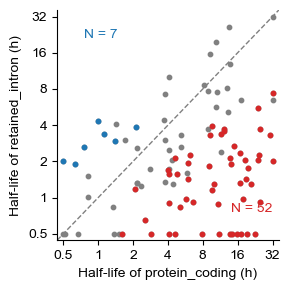

--------------------------------------------------------------------------------
Path: results/change_of_ntr/K562_FUCCI_S2.s4U_50uM_3h.mRNA_RI.csv
All: 125
protein_coding longer: 72
retained_intron longer 7


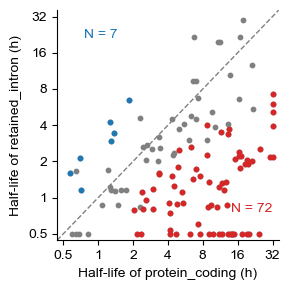

--------------------------------------------------------------------------------
Path: results/change_of_ntr/MouseBlastocyst_EPI.s4U_400uM_3h.mRNA_RI.csv
All: 29
protein_coding longer: 20
retained_intron longer 0


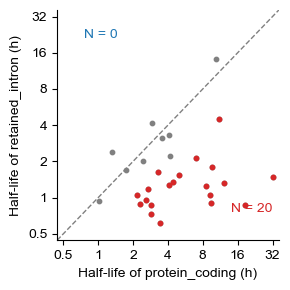

--------------------------------------------------------------------------------
Path: results/change_of_ntr/MouseBlastocyst_EarlyTE.s4U_400uM_3h.mRNA_RI.csv
All: 59
protein_coding longer: 30
retained_intron longer 1


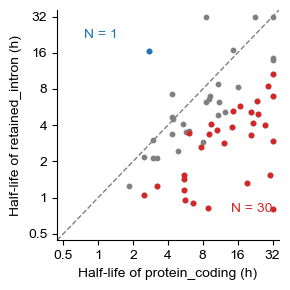

--------------------------------------------------------------------------------
Path: results/change_of_ntr/MouseBlastocyst_ICM-1.s4U_400uM_3h.mRNA_RI.csv
All: 37
protein_coding longer: 13
retained_intron longer 0


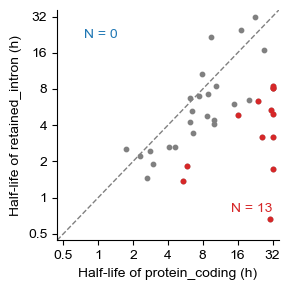

--------------------------------------------------------------------------------
Path: results/change_of_ntr/MouseBlastocyst_ICM-2.s4U_400uM_3h.mRNA_RI.csv
All: 28
protein_coding longer: 17
retained_intron longer 1


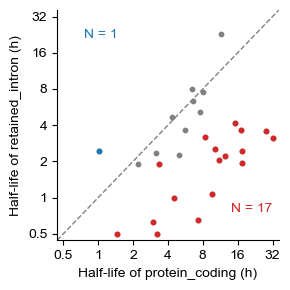

--------------------------------------------------------------------------------
Path: results/change_of_ntr/MouseBlastocyst_ICM.s4U_400uM_3h.mRNA_RI.csv
All: 99
protein_coding longer: 51
retained_intron longer 3


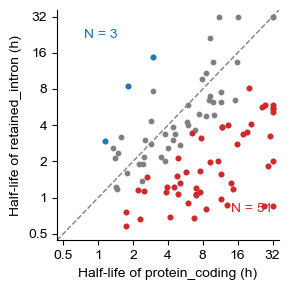

--------------------------------------------------------------------------------
Path: results/change_of_ntr/MouseBlastocyst_LateTE.s4U_400uM_3h.mRNA_RI.csv
All: 31
protein_coding longer: 17
retained_intron longer 0


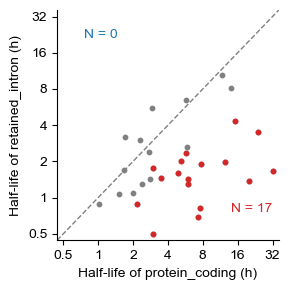

--------------------------------------------------------------------------------
Path: results/change_of_ntr/MouseBlastocyst_PE.s4U_400uM_3h.mRNA_RI.csv
All: 18
protein_coding longer: 7
retained_intron longer 0


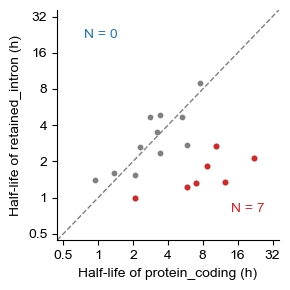

--------------------------------------------------------------------------------
Path: results/change_of_ntr/MouseBlastocyst_TE-1.s4U_400uM_3h.mRNA_RI.csv
All: 17
protein_coding longer: 8
retained_intron longer 0


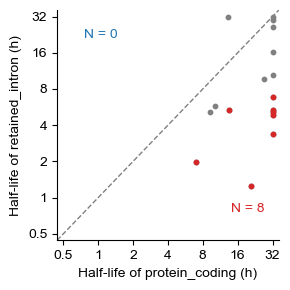

--------------------------------------------------------------------------------
Path: results/change_of_ntr/MouseBlastocyst_TE-2.s4U_400uM_3h.mRNA_RI.csv
All: 30
protein_coding longer: 17
retained_intron longer 1


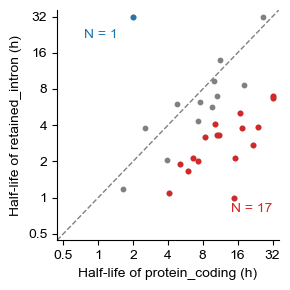

--------------------------------------------------------------------------------
Path: results/change_of_ntr/MouseBlastocyst_muralTE.s4U_400uM_3h.mRNA_RI.csv
All: 7
protein_coding longer: 4
retained_intron longer 0


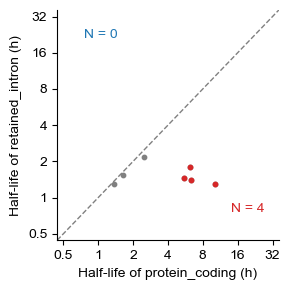

--------------------------------------------------------------------------------
Path: results/change_of_ntr/MouseBlastocyst_polarTE.s4U_400uM_3h.mRNA_RI.csv
All: 16
protein_coding longer: 9
retained_intron longer 0


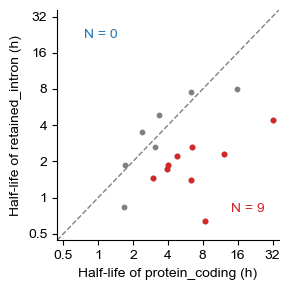

--------------------------------------------------------------------------------
Path: results/change_of_ntr/mESC.s4U_400uM_3h.highTC.mRNA_RI.csv
All: 25
protein_coding longer: 13
retained_intron longer 0


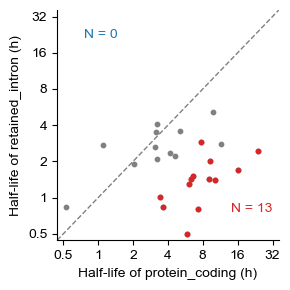

--------------------------------------------------------------------------------
Path: results/change_of_ntr/mESC.s4U_400uM_3h.mRNA_RI.csv
All: 25
protein_coding longer: 13
retained_intron longer 0


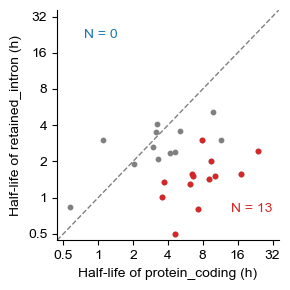

--------------------------------------------------------------------------------
Path: results/change_of_ntr/mESC_EXOSC2_IAA_0h.s4U_400uM_1h.mRNA_RI.csv
All: 106
protein_coding longer: 59
retained_intron longer 1


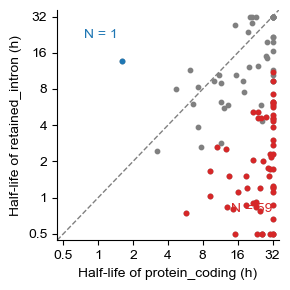

--------------------------------------------------------------------------------
Path: results/change_of_ntr/mESC_EXOSC2_IAA_0h.s4U_400uM_3h.mRNA_RI.csv
All: 111
protein_coding longer: 55
retained_intron longer 3


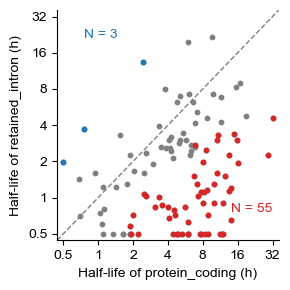

--------------------------------------------------------------------------------
Path: results/change_of_ntr/mESC_EXOSC2_IAA_12h.s4U_400uM_1h.mRNA_RI.csv
All: 112
protein_coding longer: 16
retained_intron longer 1


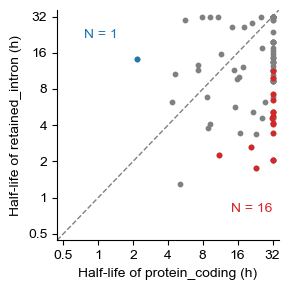

--------------------------------------------------------------------------------
Path: results/change_of_ntr/mESC_EXOSC2_IAA_12h.s4U_400uM_3h.mRNA_RI.csv
All: 105
protein_coding longer: 33
retained_intron longer 5


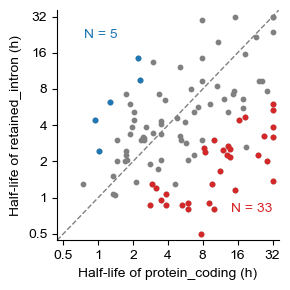

--------------------------------------------------------------------------------
Path: results/change_of_ntr/mESC_EXOSC2_IAA_4h.s4U_400uM_1h.mRNA_RI.csv
All: 119
protein_coding longer: 47
retained_intron longer 1


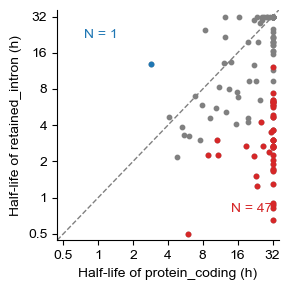

--------------------------------------------------------------------------------
Path: results/change_of_ntr/mESC_EXOSC2_IAA_4h.s4U_400uM_3h.mRNA_RI.csv
All: 114
protein_coding longer: 63
retained_intron longer 2


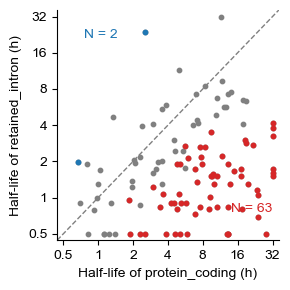

In [36]:
def limit_halflife(time, ntrs, tmin, tmax):
    hts = []
    for ntr in ntrs:
        if ntr == 0:
            hts.append(tmax)
        elif ntr == 1:
            hts.append(tmin)
        else:
            ht = -time/np.log2(1-ntr)
            ht = max(min(ht, tmax), tmin)
            hts.append(ht)
    return hts

def plot_change_of_halflife_mRNA_RI(infile, min_umis=20, diff_ntr=0.1, pval=0.05, fdr=None, outfile=None):
    m = pd.read_csv(infile)

    # Half-life
    if name == "K562":
        x1, x2 = -1, 7
    else:
        x1, x2 = -1, 5
    w = x2 - x1
    m = m[m["Total.Min"] >= min_umis].copy()
    m["Halflife.1"] = limit_halflife(3, m["NTR.1"], 2**x1, 2**x2)
    m["Halflife.2"] = limit_halflife(3, m["NTR.2"], 2**x1, 2**x2)
    if fdr is not None:
        m1 = m[(m["NTR.Diff"] > diff_ntr) & (m["FDR"] < fdr)]
        m2 = m[(m["NTR.Diff"] < -diff_ntr) & (m["FDR"] < fdr)]
    else:
        m1 = m[(m["NTR.Diff"] > diff_ntr) & (m["Pvalue"] < pval)]
        m2 = m[(m["NTR.Diff"] < -diff_ntr) & (m["Pvalue"] < pval)]
    xs, ys = np.log2(m["Halflife.1"]), np.log2(m["Halflife.2"])
    xs1, ys1 = np.log2(m1["Halflife.1"]), np.log2(m1["Halflife.2"])
    xs2, ys2 = np.log2(m2["Halflife.1"]), np.log2(m2["Halflife.2"])
    s = 10
    plt.figure(figsize=(3, 3))
    plt.scatter(xs, ys, s=s, color="grey", clip_on=False)
    plt.scatter(xs1, ys1, s=s, color="C3", clip_on=False)
    plt.scatter(xs2, ys2, s=s,color="C0", clip_on=False)
    print("All:", len(xs))
    print("protein_coding longer:", len(xs1))
    print("retained_intron longer", len(xs2))
    plt.text(x1 + w * 0.8, x1 + w * 0.1, "N = %d" % len(m1), color="C3")
    plt.text(x1 + w * 0.1, x1 + w * 0.9, "N = %d" % len(m2), color="C0")
    plt.plot([x1 - w * 0.03, x2 + w * 0.03], [x1 - w * 0.03, x2 + w * 0.03], lw=1, ls="--", color="grey")
    plt.xlim(x1 - w * 0.03, x2 + w * 0.03)
    plt.ylim(x1 - w * 0.03, x2 + w * 0.03)
    plt.xlabel("Half-life of protein_coding (h)")
    plt.ylabel("Half-life of retained_intron (h)")
    vs = np.arange(x1, x2 + 1)
    plt.xticks(vs, [2**int(v) for v in vs])
    plt.yticks(vs, [2**int(v) for v in vs])
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile)
    plt.show()
    plt.close()

for path in sorted(glob.glob("results/change_of_ntr/*.mRNA_RI.csv")):
    name = path.split("/")[-1][:-12]
    print("-" * 80)
    print("Path:", path)
    
    plot_change_of_halflife_mRNA_RI(
        infile=path,
        min_umis=20 if name.startswith("MouseBlastocyst") else 10, # 10 or 20,
        diff_ntr=0.1,
        fdr=0.05,
        outfile="figures/change_of_halflife/change_of_halflife.mRNA_RI.%s.pdf" % name
    )

# Plot change of NTR (mRNA vs. mRNA)

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_15min


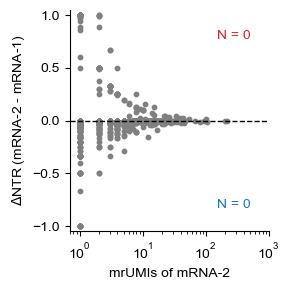

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_1h


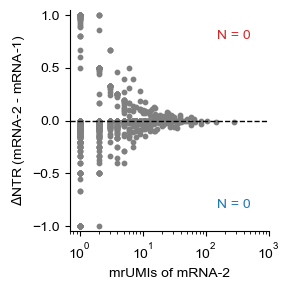

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_2h


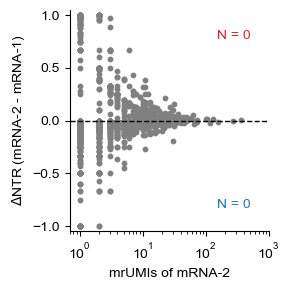

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_30min


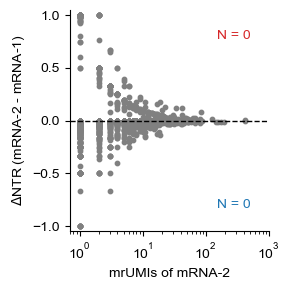

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_3h


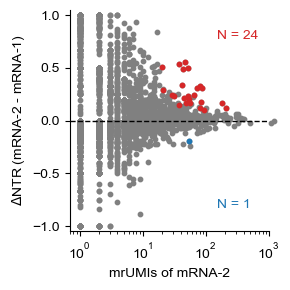

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_3h.highTC


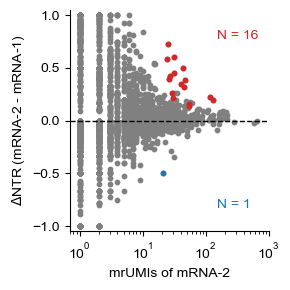

--------------------------------------------------------------------------------
Name: K562_FUCCI_G1.s4U_50uM_2h


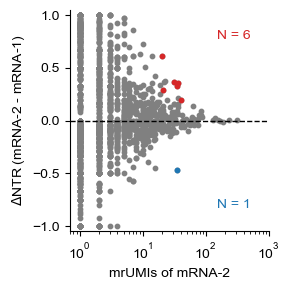

--------------------------------------------------------------------------------
Name: K562_FUCCI_G1.s4U_50uM_3h


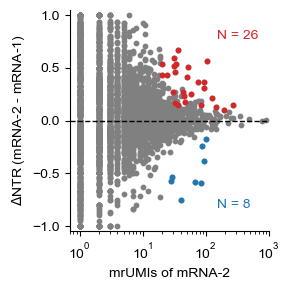

--------------------------------------------------------------------------------
Name: K562_FUCCI_G2M.s4U_50uM_3h


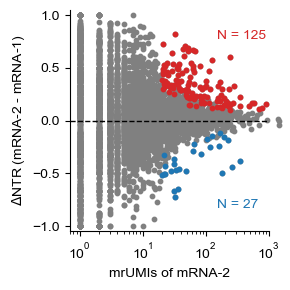

--------------------------------------------------------------------------------
Name: K562_FUCCI_S1.s4U_50uM_3h


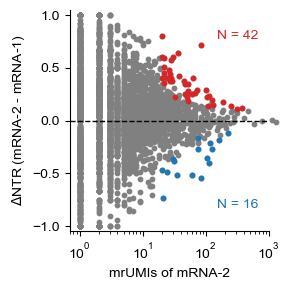

--------------------------------------------------------------------------------
Name: K562_FUCCI_S2.s4U_50uM_3h


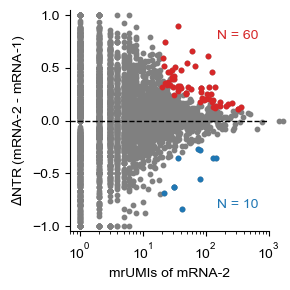

--------------------------------------------------------------------------------
Name: MouseBlastocyst_EPI.s4U_400uM_3h


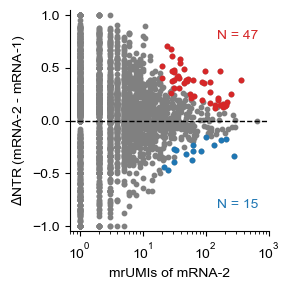

--------------------------------------------------------------------------------
Name: MouseBlastocyst_EarlyTE.s4U_400uM_3h


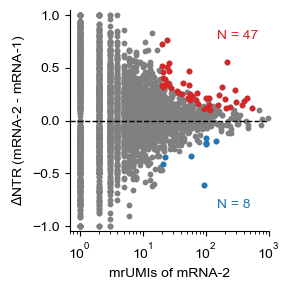

--------------------------------------------------------------------------------
Name: MouseBlastocyst_ICM-1.s4U_400uM_3h


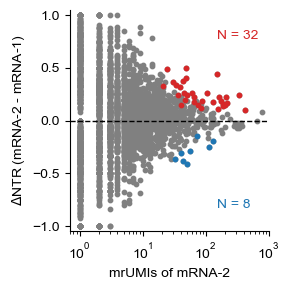

--------------------------------------------------------------------------------
Name: MouseBlastocyst_ICM-2.s4U_400uM_3h


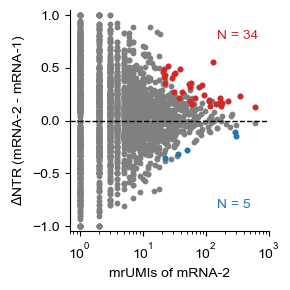

--------------------------------------------------------------------------------
Name: MouseBlastocyst_ICM.s4U_400uM_3h


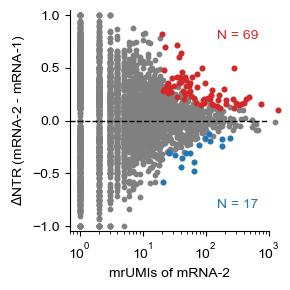

--------------------------------------------------------------------------------
Name: MouseBlastocyst_LateTE.s4U_400uM_3h


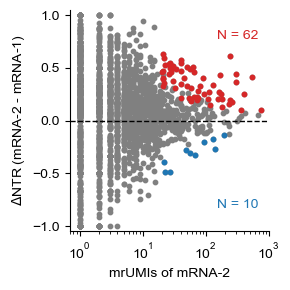

--------------------------------------------------------------------------------
Name: MouseBlastocyst_PE.s4U_400uM_3h


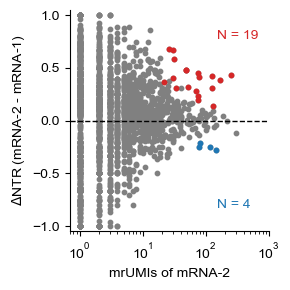

--------------------------------------------------------------------------------
Name: MouseBlastocyst_TE-1.s4U_400uM_3h


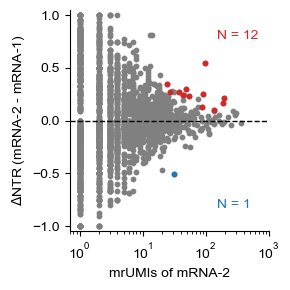

--------------------------------------------------------------------------------
Name: MouseBlastocyst_TE-2.s4U_400uM_3h


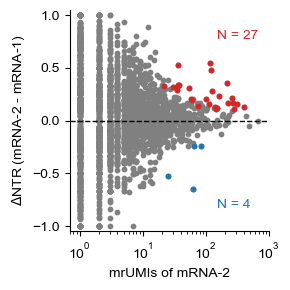

--------------------------------------------------------------------------------
Name: MouseBlastocyst_muralTE.s4U_400uM_3h


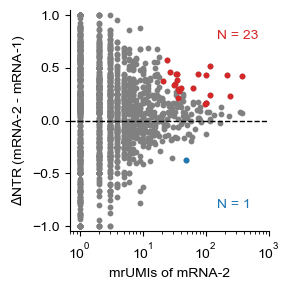

--------------------------------------------------------------------------------
Name: MouseBlastocyst_polarTE.s4U_400uM_3h


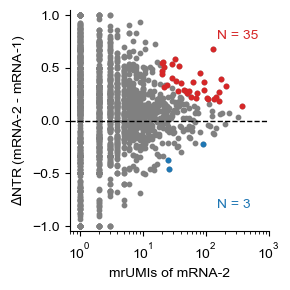

--------------------------------------------------------------------------------
Name: mESC.s4U_400uM_3h


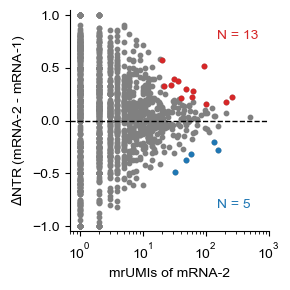

--------------------------------------------------------------------------------
Name: mESC.s4U_400uM_3h.highTC


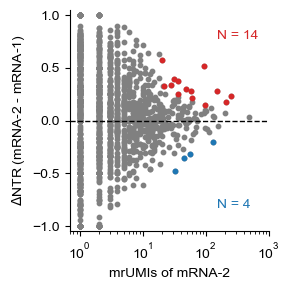

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_0h.s4U_400uM_1h


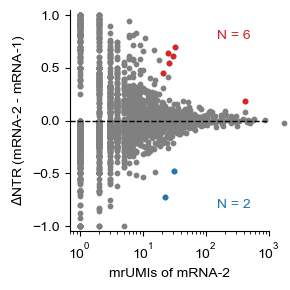

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_0h.s4U_400uM_3h


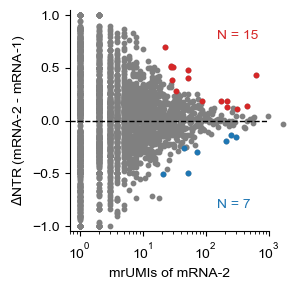

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_12h.s4U_400uM_1h


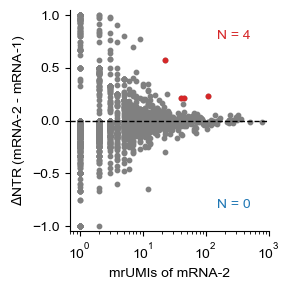

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_12h.s4U_400uM_3h


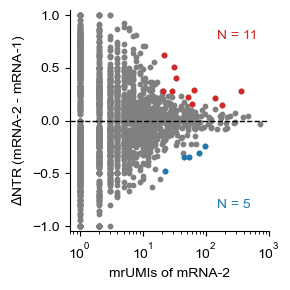

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_4h.s4U_400uM_1h


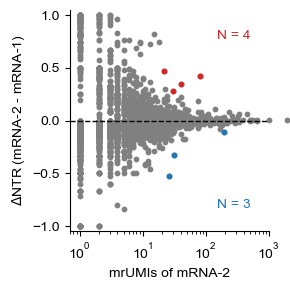

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_4h.s4U_400uM_3h


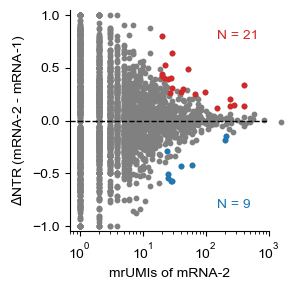

In [39]:
def plot_change_of_ntr_mRNA_mRNA(infile, min_umis=20, diff_ntr=0.1, pval=0.05, fdr=None, outfile=None, outfile2=None):
    m = pd.read_csv(infile)
    m = m[(m["TranscriptType.1"] == "protein_coding") & (m["TranscriptType.2"] == "protein_coding")]
    m = m[~m["GeneName"].duplicated()]
    tmp = m[m["Total.2"] >= min_umis].copy()
    tmp["FDR"] = multipletests(tmp["Pvalue"], method='fdr_bh')[1]
    if fdr is None:
        m1 = tmp[(tmp["NTR.Diff"] > diff_ntr) & (tmp["Pvalue"] < pval)]
        m2 = tmp[(tmp["NTR.Diff"] < -diff_ntr) & (tmp["Pvalue"] < pval)]
    else:
        m1 = tmp[(tmp["NTR.Diff"] > diff_ntr) & (tmp["FDR"] < fdr)]
        m2 = tmp[(tmp["NTR.Diff"] < -diff_ntr) & (tmp["FDR"] < fdr)]       
    xs, ys = m["Total.Min"], m["NTR.Diff"]
    xs1, ys1 = m1["Total.Min"], m1["NTR.Diff"]
    xs2, ys2 = m2["Total.Min"], m2["NTR.Diff"]
    if outfile2:
        m.merge(tmp[["FDR"]], left_index=True, right_index=True, how="left").to_csv(outfile2, index=False)

    plt.figure(figsize=(3, 3))
    plt.scatter(xs, ys, marker="o", s=10, color="grey", clip_on=False)
    plt.scatter(xs1, ys1, marker="o", s=10, color="C3", clip_on=False)
    plt.scatter(xs2, ys2, marker="o", s=10, color="C0", clip_on=False)
    plt.text(150, 0.8, "N = %d" % len(xs1), ha="left", va="center", color="C3")
    plt.text(150, -0.8, "N = %d" % len(xs2), ha="left", va="center", color="C0")
    plt.axhline(0, lw=1, ls="--", color="black")
    plt.xscale("log")
    plt.xlim(0.7, 1000)
    plt.ylim(-1.05, 1.05)
    
    if "PolarTE" in infile:
        # tnames = ["Cdc42-201", "Cdc42-202", "Dppa1-201", "Dppa1-202"]
        highlight_genes = ["Cdc42", "Dppa1"]
        highlight_genes = ["Cdc42"]
        for gname in highlight_genes:
            tmp = m[m["GeneName"] == gname]
            print(tmp["TranscriptName.1"].values[0])
            print(tmp["TranscriptName.2"].values[0])
            xs3, ys3 = tmp["Total.Min"].values, tmp["NTR.Diff"].values
            print(gname, xs3[0], ys3[0], sep="\t")
            plt.scatter(xs3, ys3, marker="o", s=10, color="C2", clip_on=False)

    plt.xlabel("mrUMIs of mRNA-2")
    plt.ylabel("$\Delta$NTR (mRNA-2 - mRNA-1)")
    for loc in ["top", "right"]:
        plt.gca().spines[loc].set_visible(False)
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile)
    plt.show()
    plt.close()


# Report

for path in sorted(glob.glob("results/pairwise_transcripts/*.csv")):
    name = path.split("/")[-1][:-4]
    if name.startswith("K562") and "s4U_50uM" not in name:
        continue
    if name.startswith("mESC") and "s4U_400uM" not in name:
        continue
    if name.startswith("MouseBlastocyst") and "s4U_400uM" not in name:
        continue
        
    print("-" * 80)
    print("Name:", name)
    
    plot_change_of_ntr_mRNA_mRNA(
        infile=path,
        min_umis=20,
        diff_ntr=0.1,
        fdr=0.01,
        # outfile="figures/change_of_ntr/change_of_ntr.mRNA_mRNA.%s.pdf" % name,
        outfile2="results/change_of_ntr/%s.mRNA_mRNA.csv" % name,
    )

# Plot change of halflife (mRNA vs. mRNA)

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_15min
59 0 0


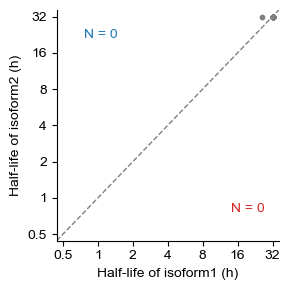

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_1h
61 0 0


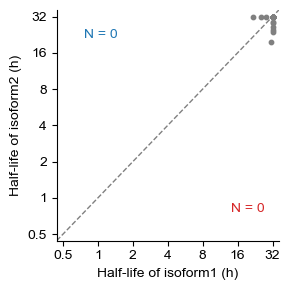

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_2h
91 0 0


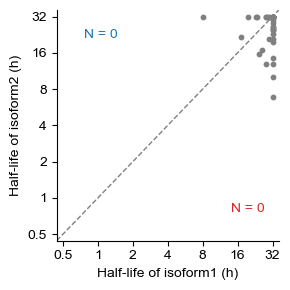

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_30min
149 0 0


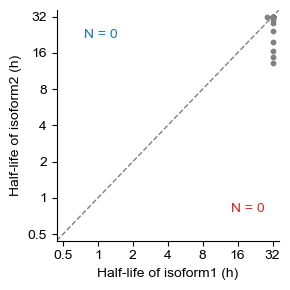

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_3h.highTC
208 24 3


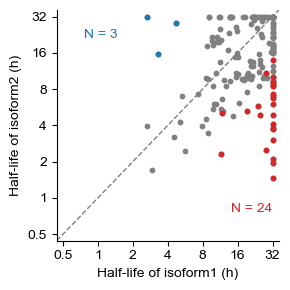

--------------------------------------------------------------------------------
Name: K562.s4U_50uM_3h
379 34 2


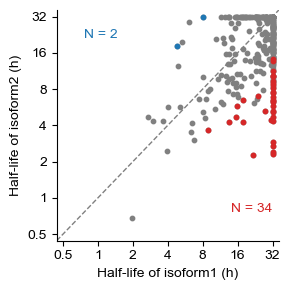

--------------------------------------------------------------------------------
Name: K562_FUCCI_G1.s4U_50uM_2h
101 10 1


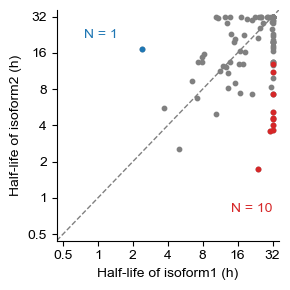

--------------------------------------------------------------------------------
Name: K562_FUCCI_G1.s4U_50uM_3h
322 37 10


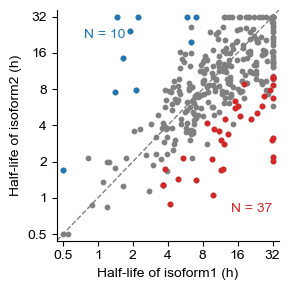

--------------------------------------------------------------------------------
Name: K562_FUCCI_G2M.s4U_50uM_3h
902 179 40


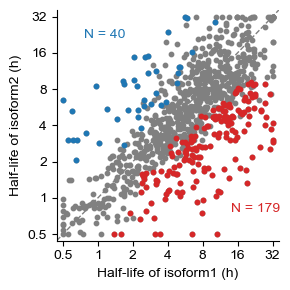

--------------------------------------------------------------------------------
Name: K562_FUCCI_S1.s4U_50uM_3h
446 58 28


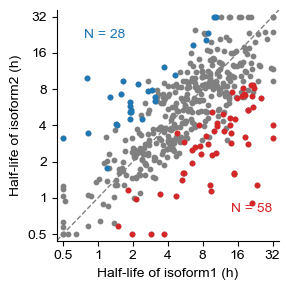

--------------------------------------------------------------------------------
Name: K562_FUCCI_S2.s4U_50uM_3h
513 71 22


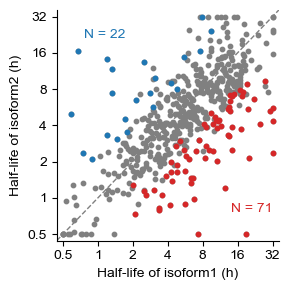

--------------------------------------------------------------------------------
Name: MouseBlastocyst_EPI.s4U_400uM_3h
276 62 24


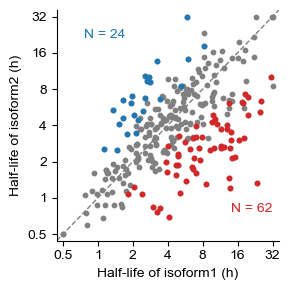

--------------------------------------------------------------------------------
Name: MouseBlastocyst_EarlyTE.s4U_400uM_3h
508 73 18


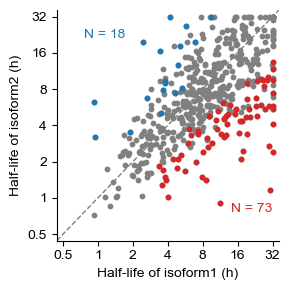

--------------------------------------------------------------------------------
Name: MouseBlastocyst_ICM-1.s4U_400uM_3h
332 41 12


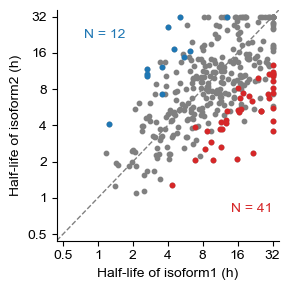

--------------------------------------------------------------------------------
Name: MouseBlastocyst_ICM-2.s4U_400uM_3h
270 48 11


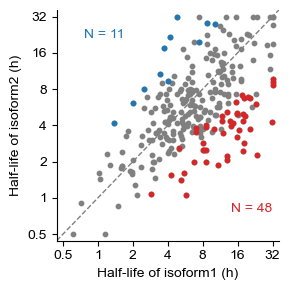

--------------------------------------------------------------------------------
Name: MouseBlastocyst_ICM.s4U_400uM_3h
581 98 33


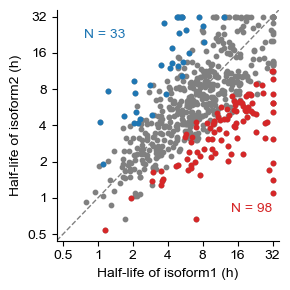

--------------------------------------------------------------------------------
Name: MouseBlastocyst_LateTE.s4U_400uM_3h
250 80 11


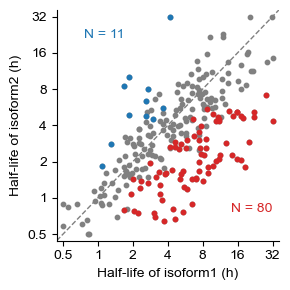

--------------------------------------------------------------------------------
Name: MouseBlastocyst_PE.s4U_400uM_3h
168 30 7


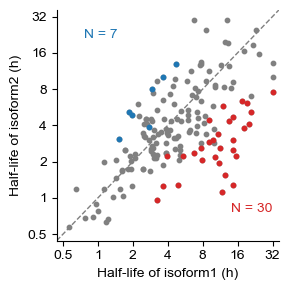

--------------------------------------------------------------------------------
Name: MouseBlastocyst_TE-1.s4U_400uM_3h
206 18 4


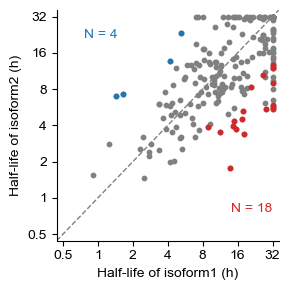

--------------------------------------------------------------------------------
Name: MouseBlastocyst_TE-2.s4U_400uM_3h
282 40 6


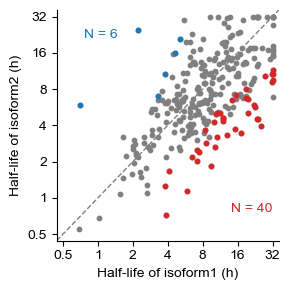

--------------------------------------------------------------------------------
Name: MouseBlastocyst_muralTE.s4U_400uM_3h
115 28 2


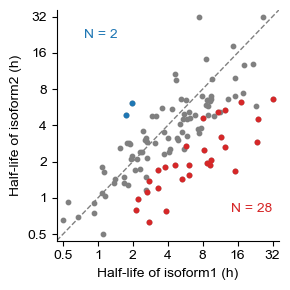

--------------------------------------------------------------------------------
Name: MouseBlastocyst_polarTE.s4U_400uM_3h
145 38 8


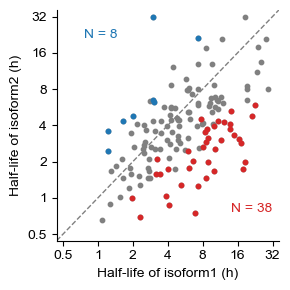

--------------------------------------------------------------------------------
Name: mESC.s4U_400uM_3h.highTC
108 16 6


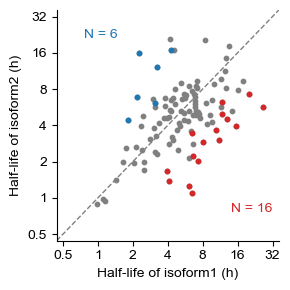

--------------------------------------------------------------------------------
Name: mESC.s4U_400uM_3h
111 15 7


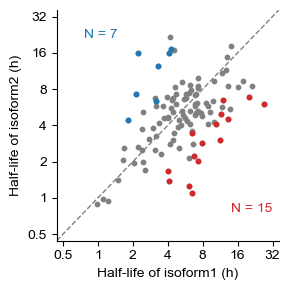

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_0h.s4U_400uM_1h
337 10 2


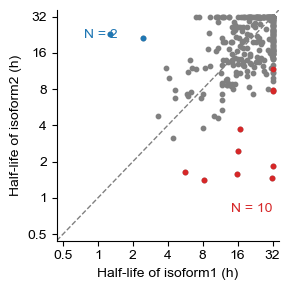

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_0h.s4U_400uM_3h
352 28 14


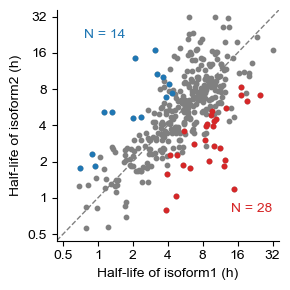

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_12h.s4U_400uM_1h
212 4 1


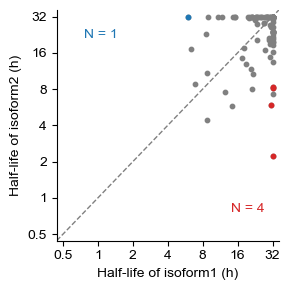

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_12h.s4U_400uM_3h
207 11 7


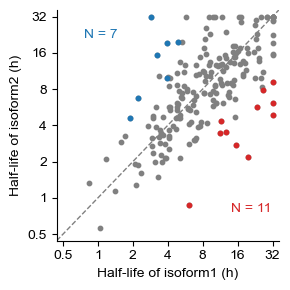

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_4h.s4U_400uM_1h
362 9 3


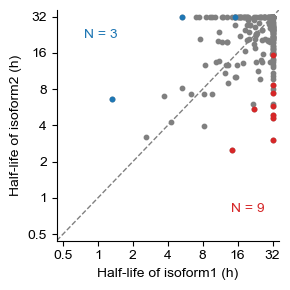

--------------------------------------------------------------------------------
Name: mESC_EXOSC2_IAA_4h.s4U_400uM_3h
323 33 15


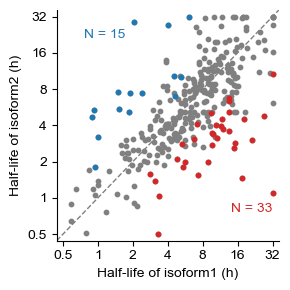

In [44]:
def limit_halflife(time, ntrs, tmin, tmax):
    hts = []
    for ntr in ntrs:
        if ntr == 0:
            hts.append(tmax)
        elif ntr == 1:
            hts.append(tmin)
        else:
            ht = -time/np.log2(1-ntr)
            ht = max(min(ht, tmax), tmin)
            hts.append(ht)
    return hts

def plot_change_of_halflife_mRNA_mRNA(infile, title=None, min_umis=20, diff_ntr=0.1, pval=0.05, fdr=None, figsize=(3, 3), outfile=None):
    m = pd.read_csv(infile)
    m = m[(m["TranscriptType.1"] == "protein_coding") & (m["TranscriptType.2"] == "protein_coding") & (m["Total.1"] >= m["Total.2"])]
    m = m[~m["GeneID"].duplicated()]
    
    if name == "K562":
        x1, x2 = 0, 8
    else:
        x1, x2 = -1, 5
        
    w = x2 - x1
    m = m[m["Total.Min"] >= min_umis]
    m["FDR"] = multipletests(m["Pvalue"], method='fdr_bh')[1]
    m["Halflife.1"] = limit_halflife(3, m["NTR.1"], 2**x1, 2**x2)
    m["Halflife.2"] = limit_halflife(3, m["NTR.2"], 2**x1, 2**x2)
    if fdr is not None:
        m1 = m[(m["NTR.Diff"] > diff_ntr) & (m["FDR"] < fdr)]
        m2 = m[(m["NTR.Diff"] < -diff_ntr) & (m["FDR"] < fdr)]
    else:
        m1 = m[(m["NTR.Diff"] > diff_ntr) & (m["Pvalue"] < pval)]
        m2 = m[(m["NTR.Diff"] < -diff_ntr) & (m["Pvalue"] < pval)]
    xs, ys = np.log2(m["Halflife.1"]), np.log2(m["Halflife.2"])
    xs1, ys1 = np.log2(m1["Halflife.1"]), np.log2(m1["Halflife.2"])
    xs2, ys2 = np.log2(m2["Halflife.1"]), np.log2(m2["Halflife.2"])
    
    s = 10
    
    plt.figure(figsize=(3, 3))
    plt.title(title)
    plt.scatter(xs, ys, s=s, color="grey", clip_on=False)
    plt.scatter(xs1, ys1, s=s, color="C3", clip_on=False)
    plt.scatter(xs2, ys2, s=s,color="C0", clip_on=False)
    print(len(xs), len(xs1), len(xs2))
    plt.text(x1 + w * 0.8, x1 + w * 0.1, "N = %d" % len(m1), color="C3")
    plt.text(x1 + w * 0.1, x1 + w * 0.9, "N = %d" % len(m2), color="C0")
    plt.plot([x1 - w * 0.03, x2 + w * 0.03], [x1 - w * 0.03, x2 + w * 0.03], lw=1, ls="--", color="grey")
    plt.xlim(x1 - w * 0.03, x2 + w * 0.03)
    plt.ylim(x1 - w * 0.03, x2 + w * 0.03)
    plt.xlabel("Half-life of isoform1 (h)")
    plt.ylabel("Half-life of isoform2 (h)")
    vs = np.arange(x1, x2 + 1)
    plt.xticks(vs, [2**int(v) for v in vs])
    plt.yticks(vs, [2**int(v) for v in vs])
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile)
    plt.show()
    plt.close()


for path in sorted(glob.glob("results/change_of_ntr/*.mRNA_mRNA.csv")):    
    name = path.split("/")[-1][:-14]
    print("-" * 80)
    print("Name:", name)
    
    plot_change_of_halflife_mRNA_mRNA(
        infile=path,
        min_umis=20,
        diff_ntr=0.1,
        fdr=0.05,
        outfile="figures/change_of_halflife/change_of_halflife.mRNA_mRNA.%s.pdf" % name
    )

In [40]:
def limit_halflife(time, ntrs, tmin, tmax):
    hts = []
    for ntr in ntrs:
        if ntr == 0:
            hts.append(tmax)
        elif ntr == 1:
            hts.append(tmin)
        else:
            ht = -time/np.log2(1-ntr)
            ht = max(min(ht, tmax), tmin)
            hts.append(ht)
    return hts

def plot_change_of_halflife_mRNA_mRNA(infile, title=None, min_umis=20, diff_ntr=0.1, pval=0.05, fdr=None, figsize=(3, 3), outfile=None):
    m = pd.read_csv(infile)
    m = m[(m["TranscriptType.1"] == "protein_coding") & (m["TranscriptType.2"] == "protein_coding") & (m["Total.1"] >= m["Total.2"])]
    m = m[~m["GeneID"].duplicated()]
    
    if name == "K562":
        x1, x2 = 0, 8
    else:
        x1, x2 = -1, 5
        
    w = x2 - x1
    m = m[m["Total.Min"] >= min_umis]
    m["FDR"] = multipletests(m["Pvalue"], method='fdr_bh')[1]
    m["Halflife.1"] = limit_halflife(3, m["NTR.1"], 2**x1, 2**x2)
    m["Halflife.2"] = limit_halflife(3, m["NTR.2"], 2**x1, 2**x2)
    if fdr is not None:
        m1 = m[(m["NTR.Diff"] > diff_ntr) & (m["FDR"] < fdr)]
        m2 = m[(m["NTR.Diff"] < -diff_ntr) & (m["FDR"] < fdr)]
    else:
        m1 = m[(m["NTR.Diff"] > diff_ntr) & (m["Pvalue"] < pval)]
        m2 = m[(m["NTR.Diff"] < -diff_ntr) & (m["Pvalue"] < pval)]
    xs, ys = np.log2(m["Halflife.1"]), np.log2(m["Halflife.2"])
    xs1, ys1 = np.log2(m1["Halflife.1"]), np.log2(m1["Halflife.2"])
    xs2, ys2 = np.log2(m2["Halflife.1"]), np.log2(m2["Halflife.2"])
    
    s = 10
    
    plt.figure(figsize=(3, 3))
    plt.title(title)
    plt.scatter(xs, ys, s=s, color="grey", clip_on=False)
    plt.scatter(xs1, ys1, s=s, color="C3", clip_on=False)
    plt.scatter(xs2, ys2, s=s,color="C0", clip_on=False)
    print(len(xs), len(xs1), len(xs2))
    plt.text(x1 + w * 0.8, x1 + w * 0.1, "N = %d" % len(m1), color="C3")
    plt.text(x1 + w * 0.1, x1 + w * 0.9, "N = %d" % len(m2), color="C0")
    plt.plot([x1 - w * 0.03, x2 + w * 0.03], [x1 - w * 0.03, x2 + w * 0.03], lw=1, ls="--", color="grey")
    plt.xlim(x1 - w * 0.03, x2 + w * 0.03)
    plt.ylim(x1 - w * 0.03, x2 + w * 0.03)
    plt.xlabel("Half-life of isoform1 (h)")
    plt.ylabel("Half-life of isoform2 (h)")
    vs = np.arange(x1, x2 + 1)
    plt.xticks(vs, [2**int(v) for v in vs])
    plt.yticks(vs, [2**int(v) for v in vs])
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile)
    plt.show()
    plt.close()

for path in sorted(glob.glob("results/pairwise_transcripts/*.csv")):
    name = path.split("/")[-1][:-4]
    if "_50uM_" not in name and "_400uM_" not in name:
        continue
        
    print("-" * 80)
    print("Name:", name)
    
    plot_change_of_halflife_mRNA_mRNA(
        infile="results/pairwise_isoforms/%s.csv" % name,
        min_umis=20,
        diff_ntr=0.1,
        fdr=0.01,
        # outfile="figures/change_of_halflife/change_of_halflife.mRNA_mRNA.%s.pdf" % name
    )

# Report decay diversity table

In [5]:
cts = [
    "K562.s4U_50uM_3h.highTC",
    "mESC.s4U_400uM_3h.highTC",
    "MouseBlastocyst_ICM-1.s4U_400uM_3h",
    "MouseBlastocyst_ICM-2.s4U_400uM_3h",
    "MouseBlastocyst_EPI.s4U_400uM_3h",
    "MouseBlastocyst_PE.s4U_400uM_3h",
    "MouseBlastocyst_TE-1.s4U_400uM_3h",
    "MouseBlastocyst_TE-2.s4U_400uM_3h",
    "MouseBlastocyst_muralTE.s4U_400uM_3h",
    "MouseBlastocyst_polarTE.s4U_400uM_3h",
]

ds = []
for ct in cts:
    d = pd.read_csv("results/change_of_ntr/%s.mRNA_RI.csv" % ct)
    d = d[~d["FDR"].isna()].copy()
    d["CellType"] = ct.split(".")[0]
    ds.append(d)

    d = pd.read_csv("results/change_of_ntr/%s.mRNA_mRNA.csv" % ct)
    d = d[~d["FDR"].isna()].copy()
    d["CellType"] = ct.split(".")[0]
    ds.append(d)

In [8]:
m = pd.concat(ds, ignore_index=True)
m.to_csv("results/decay_diversity.csv", index=False)

# Difference of TSS

In [50]:
for infile in sorted(glob.glob("results/pairwise_transcripts/*.csv")):
    print(infile)
    name = infile.split("/")[-1][:-4]
    
    print("-" * 80)
    print("Name:", name)
    
    if "K562" in name:
        path = "/home/chenzonggui/species/homo_sapiens/GRCh38.p13/gencode.v39.annotation.transcripts.bed.gz"
    else:
        path = "/home/chenzonggui/species/mus_musculus/GRCm38.p6/gencode.vM25.annotation.transcripts.bed.gz"
    transcripts = {t.name: t for t in BedFile(path)}
        
    m = pd.read_csv(infile)
    m = m[(m["TranscriptType.1"] == "protein_coding") & (m["TranscriptType.2"] == "protein_coding") & (m["Total.1"] >= m["Total.2"])]
    m = m[~m["GeneID"].duplicated()]

    m1 = m[(m["Total.Min"] >= 10) & (m["NTR.Diff"] > 0.1) & (m["Pvalue"] < 0.05)]
    m2 = m[(m["Total.Min"] >= 10) & (m["NTR.Diff"] < -0.1) & (m["Pvalue"] < 0.05)]
    xs, ys = m["Total.Min"], m["NTR.Diff"]
    xs1, ys1 = m1["Total.Min"], m1["NTR.Diff"]
    xs2, ys2 = m2["Total.Min"], m2["NTR.Diff"]

    m3 = pd.concat([m1, m2])
    vs = []
    for gid, tid1, tid2 in m3[["GeneID", "TranscriptID.1", "TranscriptID.2"]].values:
        t1 = transcripts[tid1]
        t2 = transcripts[tid2]
        if t1.strand == "+":
            vs.append(abs(t1.start - t2.start))
        else:
            vs.append(abs(t1.end - t2.end))
        # if gid in ["ENSG00000205937.12", "ENSG00000146701.12"]:
        #     print(gid, vs[-1])
    vs = np.array(vs)
    n1 = sum(vs < 500)
    n2 = sum(vs >= 1000)
    n3 = len(vs) - n1 - n2
    print("TSS diff < 500:", n1)
    print("500 <= TSS diff < 1000:", n3)
    print("TSS diff >= 1000:", n2)

results/pairwise_transcripts/K562.csv
--------------------------------------------------------------------------------
Name: K562
TSS diff < 500: 97
500 <= TSS diff < 1000: 5
TSS diff >= 1000: 4
results/pairwise_transcripts/K562.s4U_0uM_3h.csv
--------------------------------------------------------------------------------
Name: K562.s4U_0uM_3h
TSS diff < 500: 0
500 <= TSS diff < 1000: 0
TSS diff >= 1000: 0
results/pairwise_transcripts/K562.s4U_100uM_3h.csv
--------------------------------------------------------------------------------
Name: K562.s4U_100uM_3h
TSS diff < 500: 4
500 <= TSS diff < 1000: 0
TSS diff >= 1000: 0
results/pairwise_transcripts/K562.s4U_200uM_3h.csv
--------------------------------------------------------------------------------
Name: K562.s4U_200uM_3h
TSS diff < 500: 1
500 <= TSS diff < 1000: 0
TSS diff >= 1000: 0
results/pairwise_transcripts/K562.s4U_400uM_3h.csv
--------------------------------------------------------------------------------
Name: K562.s4U_40

In [15]:
for name in params.keys():
    print("-" * 80)
    print("Name:", name)
    
    if "K562" in name:
        path = "/home/chenzonggui/species/homo_sapiens/GRCh38.p13/gencode.v39.annotation.transcripts.bed.gz"
    else:
        path = "/home/chenzonggui/species/mus_musculus/GRCm38.p6/gencode.vM25.annotation.transcripts.bed.gz"
    transcripts = {t.name: t for t in BedFile(path)}
        
    m = pd.read_csv("results/pairwise_isoform_halflife.%s.tsv" % name, sep="\t")
    m = m[(m["TranscriptType1"] == "protein_coding") & (m["TranscriptType2"] == "protein_coding") & (m["Total1"] >= m["Total2"])]
    m = m[~m["GeneID"].duplicated()]

    m1 = m[(m["Total.Min"] >= 10) & (m["NTR.Diff"] > 0.1) & (m["Pvalue"] < 0.05)]
    m2 = m[(m["Total.Min"] >= 10) & (m["NTR.Diff"] < -0.1) & (m["Pvalue"] < 0.05)]
    xs, ys = m["Total.Min"], m["NTR.Diff"]
    xs1, ys1 = m1["Total.Min"], m1["NTR.Diff"]
    xs2, ys2 = m2["Total.Min"], m2["NTR.Diff"]

    m3 = pd.concat([m1, m2])
    vs = []
    for gid, tid1, tid2 in m3[["GeneID", "TranscriptID1", "TranscriptID2"]].values:
        t1 = transcripts[tid1]
        t2 = transcripts[tid2]
        if t1.strand == "+":
            vs.append(abs(t1.start - t2.start))
        else:
            vs.append(abs(t1.end - t2.end))
        # if gid in ["ENSG00000205937.12", "ENSG00000146701.12"]:
        #     print(gid, vs[-1])
    vs = np.array(vs)
    n1 = sum(vs < 500)
    n2 = sum(vs >= 1000)
    n3 = len(vs) - n1 - n2
    print("TSS diff < 500:", n1)
    print("500 <= TSS diff < 1000:", n3)
    print("TSS diff >= 1000:", n2)

--------------------------------------------------------------------------------
Name: K562
TSS diff < 500: 65
500 <= TSS diff < 1000: 3
TSS diff >= 1000: 0
--------------------------------------------------------------------------------
Name: mESC
TSS diff < 500: 43
500 <= TSS diff < 1000: 3
TSS diff >= 1000: 6
--------------------------------------------------------------------------------
Name: K562_FUCCI_G1
TSS diff < 500: 122
500 <= TSS diff < 1000: 5
TSS diff >= 1000: 6
--------------------------------------------------------------------------------
Name: K562_FUCCI_S1
TSS diff < 500: 193
500 <= TSS diff < 1000: 7
TSS diff >= 1000: 7
--------------------------------------------------------------------------------
Name: K562_FUCCI_S2
TSS diff < 500: 215
500 <= TSS diff < 1000: 7
TSS diff >= 1000: 8
--------------------------------------------------------------------------------
Name: K562_FUCCI_G2M
TSS diff < 500: 391
500 <= TSS diff < 1000: 12
TSS diff >= 1000: 19
---------------